In [75]:
import pandas as pd

In [76]:
df = pd.DataFrame(pd.read_csv("/Users/siddharth/Desktop/capstone/data/DataCoSupplyChainDataset.csv", encoding="latin1"))
pd.set_option('display.max_columns', None)
df.head()


,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,Customer Country,Customer Email,Customer Fname,Customer Id,Customer Lname,Customer Password,Customer Segment,Customer State,Customer Street,Customer Zipcode,Department Id,Department Name,Latitude,Longitude,Market,Order City,Order Country,Order Customer Id,order date (DateOrders),Order Id,Order Item Cardprod Id,Order Item Discount,Order Item Discount Rate,Order Item Id,Order Item Product Price,Order Item Profit Ratio,Order Item Quantity,Sales,Order Item Total,Order Profit Per Order,Order Region,Order State,Order Status,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,Puerto Rico,XXXXXXXXX,Cally,20755,Holloway,XXXXXXXXX,Consumer,PR,5365 Noble Nectar Island,725.0,2,Fitness,18.251453,-66.037056,Pacific Asia,Bekasi,Indonesia,20755,1/31/2018 22:56,77202,1360,13.110000,0.04,180517,327.75,0.29,1,327.75,314.640015,91.250000,Southeast Asia,Java Occidental,COMPLETE,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2/3/2018 22:56,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,Puerto Rico,XXXXXXXXX,Irene,19492,Luna,XXXXXXXXX,Consumer,PR,2679 Rustic Loop,725.0,2,Fitness,18.279451,-66.037064,Pacific Asia,Bikaner,India,19492,1/13/2018 12:27,75939,1360,16.389999,0.05,179254,327.75,-0.80,1,327.75,311.359985,-249.089996,South Asia,Rajastán,PENDING,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/18/2018 12:27,Standard Class
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,EE. UU.,XXXXXXXXX,Gillian,19491,Maldonado,XXXXXXXXX,Consumer,CA,8510 Round Bear Gate,95125.0,2,Fitness,37.292233,-121.881279,Pacific Asia,Bikaner,India,19491,1/13/2018 12:06,75938,1360,18.030001,0.06,179253,327.75,-0.80,1,327.75,309.720001,-247.779999,South Asia,Rajastán,CLOSED,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/17/2018 12:06,Standard Class
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,EE. UU.,XXXXXXXXX,Tana,19490,Tate,XXXXXXXXX,Home Office,CA,3200 Amber Bend,90027.0,2,Fitness,34.125946,-118.291016,Pacific Asia,Townsville,Australia,19490,1/13/2018 11:45,75937,1360,22.940001,0.07,179252,327.75,0.08,1,327.75,304.809998,22.860001,Oceania,Queensland,COMPLETE,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/16/2018 11:45,Standard Class
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,Puerto Rico,XXXXXXXXX,Orli,19489,Hendricks,XXXXXXXXX,Corporate,PR,8671 Iron Anchor Corners,725.0,2,Fitness,18.253769,-66.037048,Pacific Asia,Townsville,Australia,19489,1/13/2018 11:24,75936,1360,29.500000,0.09,179251,327.75,0.45,1,327.75,298.250000,134.210007,Oceania,Queensland,PENDING_PAYMENT,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/15/2018 11:24,Standard Class


In [77]:
print("Total no of cols:",len(df.columns))
print(df['Order Zipcode'].isna().sum() / len(df) * 100)
print(df['Product Description'].notna().sum())
print(df['Customer Email'].unique())
print(df['Product Status'].unique())

Total no of cols: 53
86.23967560201419
0
['XXXXXXXXX']
[0]


## Drop useless cols

In [78]:
cols_to_drop = ['Product Description', 'Product Image', 'Customer Password', 'Customer Email', 'Product Status', 'Order Zipcode']
df.drop(columns=cols_to_drop, axis=1, inplace=True)
print("No of cols after dropping:",len(df.columns))
print("Before dropping duplicates:",len(df))
df.drop_duplicates(inplace=True)
print("After dropping duplicates:",len(df))

No of cols after dropping: 47
Before dropping duplicates: 180519
After dropping duplicates: 180519


### Proper renaming and changing the dtype of date-columns

In [79]:
df.rename(columns={'order date (DateOrders)':'order date', 'shipping date (DateOrders)':'shipping date'}, inplace=True)
date_cols = ['order date', 'shipping date']
for col in date_cols:
    df[col] = pd.to_datetime(df[col], errors='coerce')

In [80]:
obj_cols = df.select_dtypes(include='object').columns
non_obj_cols = df.select_dtypes(exclude=['object', 'datetime']).columns
datetime_cols = df.select_dtypes(include='datetime').columns

### Object-Cols Dataframe

In [81]:
obj_df = df[obj_cols].copy()
obj_df.head()

,Type,Delivery Status,Category Name,Customer City,Customer Country,Customer Fname,Customer Lname,Customer Segment,Customer State,Customer Street,Department Name,Market,Order City,Order Country,Order Region,Order State,Order Status,Product Name,Shipping Mode
0,DEBIT,Advance shipping,Sporting Goods,Caguas,Puerto Rico,Cally,Holloway,Consumer,PR,5365 Noble Nectar Island,Fitness,Pacific Asia,Bekasi,Indonesia,Southeast Asia,Java Occidental,COMPLETE,Smart watch,Standard Class
1,TRANSFER,Late delivery,Sporting Goods,Caguas,Puerto Rico,Irene,Luna,Consumer,PR,2679 Rustic Loop,Fitness,Pacific Asia,Bikaner,India,South Asia,Rajastán,PENDING,Smart watch,Standard Class
2,CASH,Shipping on time,Sporting Goods,San Jose,EE. UU.,Gillian,Maldonado,Consumer,CA,8510 Round Bear Gate,Fitness,Pacific Asia,Bikaner,India,South Asia,Rajastán,CLOSED,Smart watch,Standard Class
3,DEBIT,Advance shipping,Sporting Goods,Los Angeles,EE. UU.,Tana,Tate,Home Office,CA,3200 Amber Bend,Fitness,Pacific Asia,Townsville,Australia,Oceania,Queensland,COMPLETE,Smart watch,Standard Class
4,PAYMENT,Advance shipping,Sporting Goods,Caguas,Puerto Rico,Orli,Hendricks,Corporate,PR,8671 Iron Anchor Corners,Fitness,Pacific Asia,Townsville,Australia,Oceania,Queensland,PENDING_PAYMENT,Smart watch,Standard Class


In [82]:
print(obj_df['Customer State'].unique())
state_map = {
    'PR': 'Puerto Rico',
    'CA': 'California',
    'NY': 'New York',
    'FL': 'Florida',
    'MA': 'Massachusetts',
    'IL': 'Illinois',
    'MT': 'Montana',
    'PA': 'Pennsylvania',
    'MI': 'Michigan',
    'TX': 'Texas',
    'DE': 'Delaware',
    'GA': 'Georgia',
    'MD': 'Maryland',
    'OH': 'Ohio',
    'HI': 'Hawaii',
    'NJ': 'New Jersey',
    'WI': 'Wisconsin',
    'AZ': 'Arizona',
    'CO': 'Colorado',
    'MN': 'Minnesota',
    'NC': 'North Carolina',
    'NM': 'New Mexico',
    'OR': 'Oregon',
    'SC': 'South Carolina',
    'VA': 'Virginia',
    'UT': 'Utah',
    'WA': 'Washington',
    'KY': 'Kentucky',
    'WV': 'West Virginia',
    'RI': 'Rhode Island',
    'CT': 'Connecticut',
    'LA': 'Louisiana',
    'TN': 'Tennessee',
    'DC': 'District of Columbia',
    'ND': 'North Dakota',
    'MO': 'Missouri',
    'IN': 'Indiana',
    'ID': 'Idaho',
    'NV': 'Nevada',
    'KS': 'Kansas',
    'AR': 'Arkansas',
    'OK': 'Oklahoma',
    'AL': 'Alabama',
    'IA': 'Iowa'
}

country_map = {
    "México": "Mexico",
    "Brasil": "Brazil",
    "Panamá": "Panama",
    "Perú": "Peru",
    "Estados Unidos": "United States",
    "Reino Unido": "United Kingdom",
    "Francia": "France",
    "Alemania": "Germany",
    "Italia": "Italy",
    "España": "Spain",
    "Países Bajos": "Netherlands",
    "Suecia": "Sweden",
    "Bélgica": "Belgium",
    "Suiza": "Switzerland",
    "SudAfrica": "South Africa",
    "Emiratos Árabes Unidos": "United Arab Emirates",
    "Sáhara Occidental": "Western Sahara",
    "Guayana Francesa": "French Guiana",
    "Myanmar (Birmania)": "Myanmar",
    "Papúa Nueva Guinea": "Papua New Guinea",
    "Nueva Zelanda": "New Zealand",
    "Bangladés": "Bangladesh",
    "Corea del Sur": "South Korea",
    "Trinidad y Tobago": "Trinidad and Tobago",
    "República Dominicana": "Dominican Republic",
    "República Checa": "Czech Republic",
}


['PR' 'CA' 'NY' 'FL' 'MA' 'IL' 'MT' 'PA' 'MI' 'TX' 'DE' 'GA' 'MD' 'OH'
 'HI' 'NJ' 'WI' 'AZ' 'CO' 'MN' 'NC' 'NM' 'OR' 'SC' 'VA' 'UT' 'WA' 'KY'
 'WV' 'RI' 'CT' 'LA' 'TN' 'DC' 'ND' 'MO' 'IN' 'ID' 'NV' 'KS' 'AR' 'OK'
 'AL' 'IA' '95758' '91732']


In [ ]:
df['Customer Country'] = df['Customer Country'].replace({'EE. UU.':'United States'})
df['Customer State'] = df['Customer State'].replace(state_map)
df["Order Country"] = df["Order Country"].replace(country_map)

### Non-Obj-Cols Dataframe

In [100]:
non_obj_df = df[non_obj_cols].copy()
non_obj_df.head()

,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Late_delivery_risk,Category Id,Customer Id,Customer Zipcode,Department Id,Latitude,Longitude,Order Customer Id,Order Id,Order Item Cardprod Id,Order Item Discount,Order Item Discount Rate,Order Item Id,Order Item Product Price,Order Item Profit Ratio,Order Item Quantity,Sales,Order Item Total,Order Profit Per Order,Product Card Id,Product Category Id,Product Price
0,3,4,91.250000,314.640015,0,73,20755,725.0,2,18.251453,-66.037056,20755,77202,1360,13.110000,0.04,180517,327.75,0.29,1,327.75,314.640015,91.250000,1360,73,327.75
1,5,4,-249.089996,311.359985,1,73,19492,725.0,2,18.279451,-66.037064,19492,75939,1360,16.389999,0.05,179254,327.75,-0.80,1,327.75,311.359985,-249.089996,1360,73,327.75
2,4,4,-247.779999,309.720001,0,73,19491,95125.0,2,37.292233,-121.881279,19491,75938,1360,18.030001,0.06,179253,327.75,-0.80,1,327.75,309.720001,-247.779999,1360,73,327.75
3,3,4,22.860001,304.809998,0,73,19490,90027.0,2,34.125946,-118.291016,19490,75937,1360,22.940001,0.07,179252,327.75,0.08,1,327.75,304.809998,22.860001,1360,73,327.75
4,2,4,134.210007,298.250000,0,73,19489,725.0,2,18.253769,-66.037048,19489,75936,1360,29.500000,0.09,179251,327.75,0.45,1,327.75,298.250000,134.210007,1360,73,327.75


In [101]:
non_obj_df.rename(columns={'Order Customer Id':'Customer Id'}, inplace=True)

In [102]:
num_cols = ['Days for shipping (real)', 'Days for shipment (scheduled)', 
            'Benefit per order', 'Sales per customer', 'Late_delivery_risk', 
            'Order Item Discount', 'Order Item Discount Rate', 'Order Item Product Price', 
            'Order Item Profit Ratio', 'Order Item Quantity', 'Sales', 
            'Order Item Total', 'Order Profit Per Order', 'Product Price']

cat_cols = ['Category Id', 'Customer Id', 'Customer Zipcode', 'Department Id', 
            'Order Id', 'Order Item Cardprod Id', 'Order Item Id', 'Product Card Id', 
            'Product Category Id']

geo_cols = ['Latitude', 'Longitude']


In [104]:
# Numeric
non_obj_df[num_cols].describe()

# Categorical
non_obj_df[cat_cols].nunique()  # Unique counts


Category Id                   51
Customer Id                20652
Customer Id                20652
Customer Zipcode             995
Department Id                 11
Order Id                   65752
Order Item Cardprod Id       118
Order Item Id             180519
Product Card Id              118
Product Category Id           51
dtype: int64

In [105]:
non_obj_df.isnull().sum()
non_obj_df.duplicated().sum()


np.int64(0)

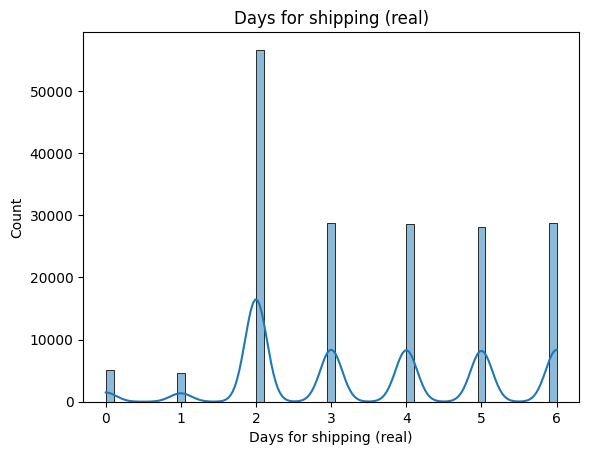

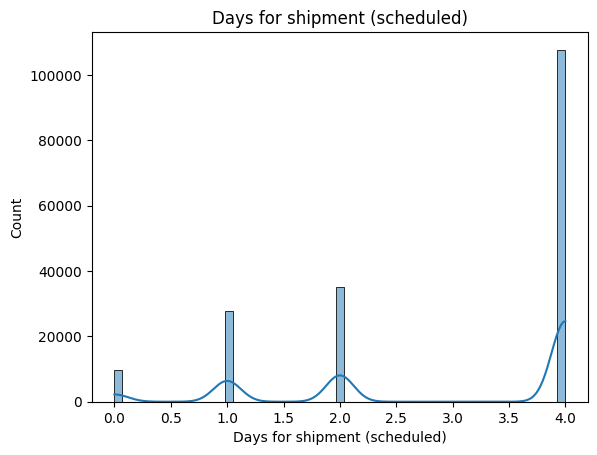

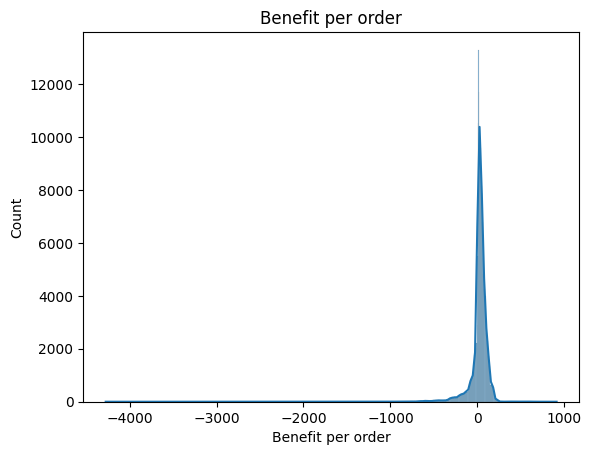

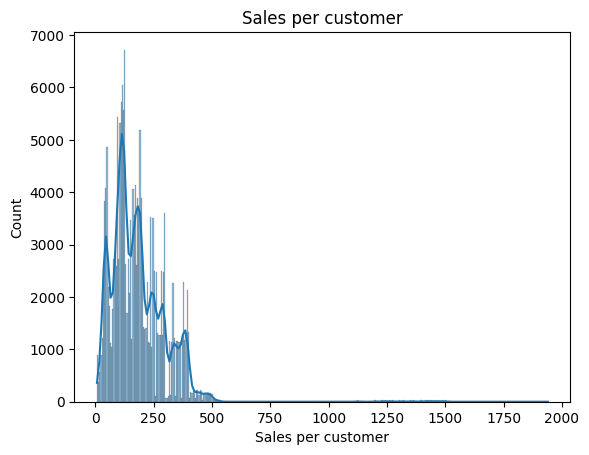

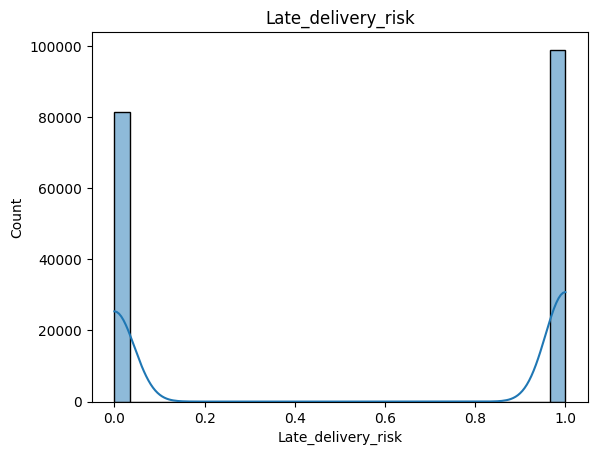

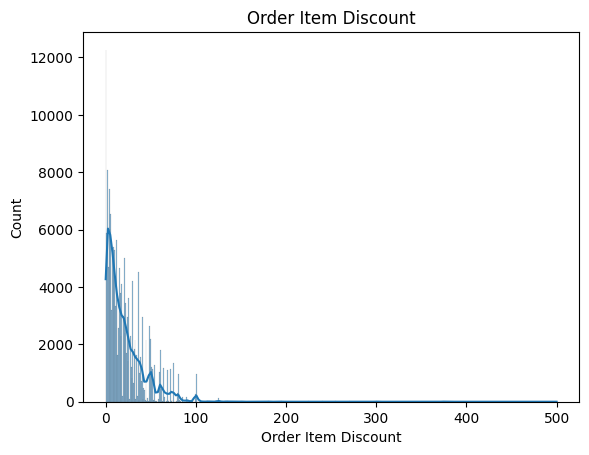

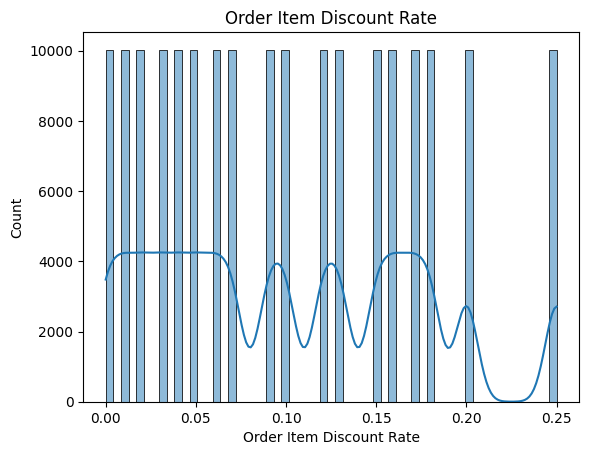

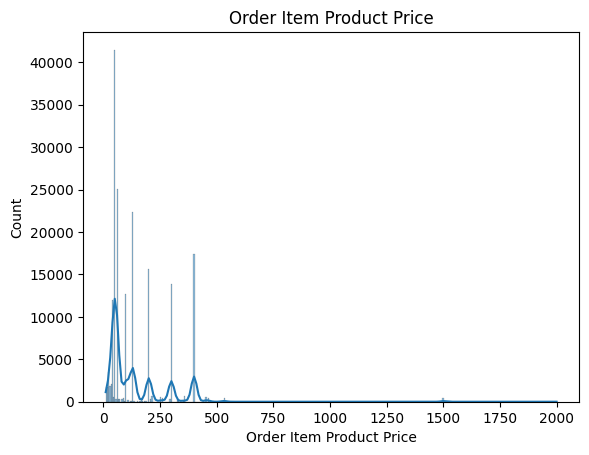

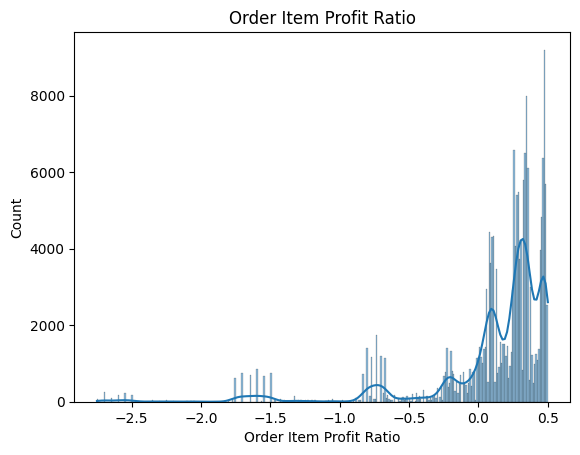

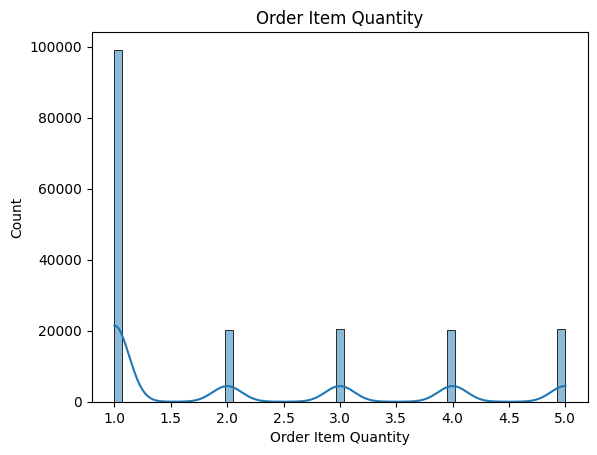

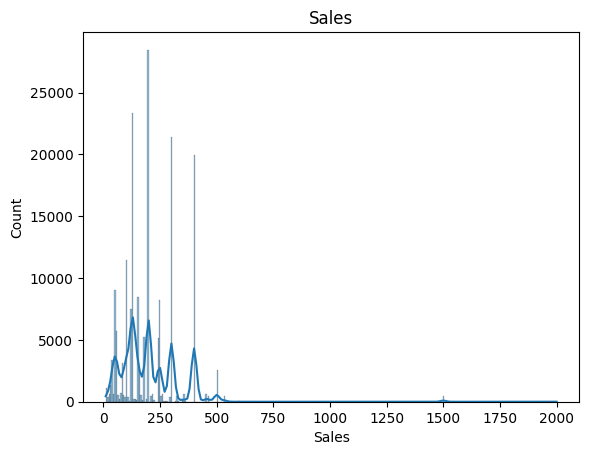

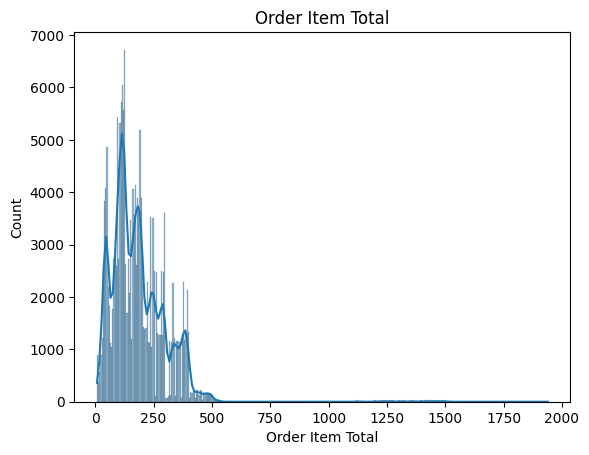

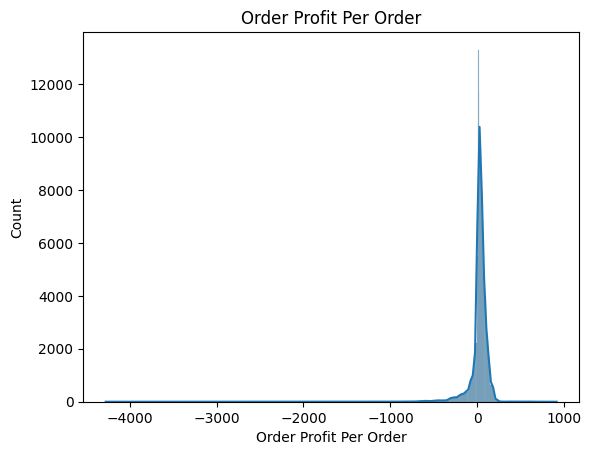

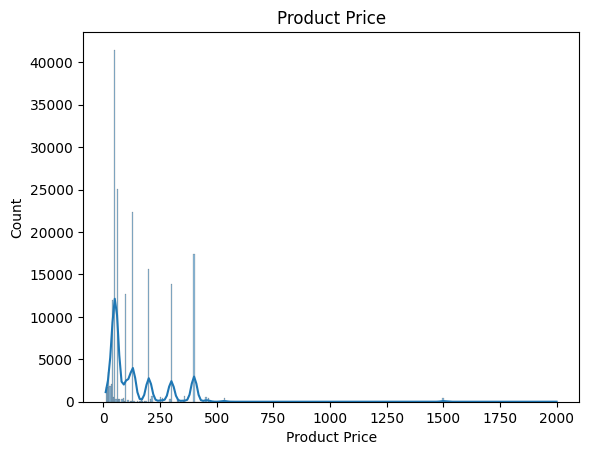

In [106]:
import seaborn as sns
import matplotlib.pyplot as plt

for col in num_cols:
    sns.histplot(non_obj_df[col], kde=True)
    plt.title(col)
    plt.show()


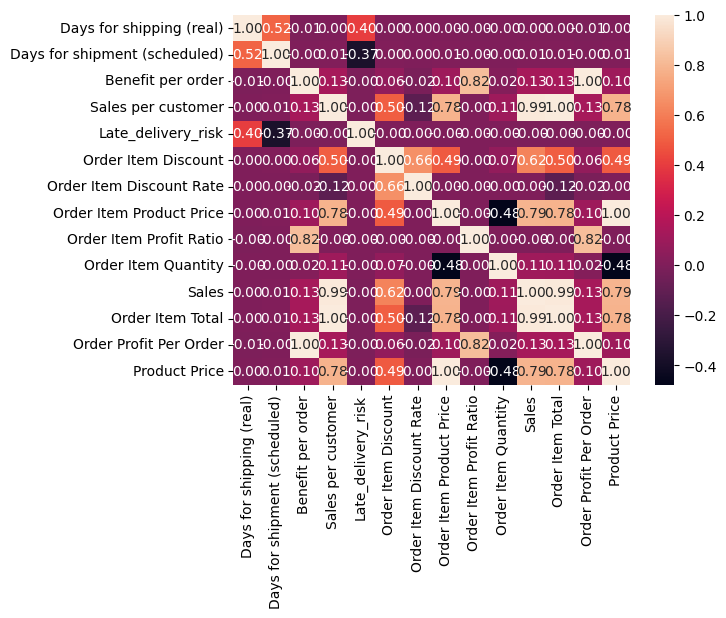

In [ ]:
corr = non_obj_df[num_cols].corr()
sns.heatmap(corr, annot=True, fmt=".2f")
plt.show()

<Axes: xlabel='Days for shipping (real)', ylabel='Late_delivery_risk'>

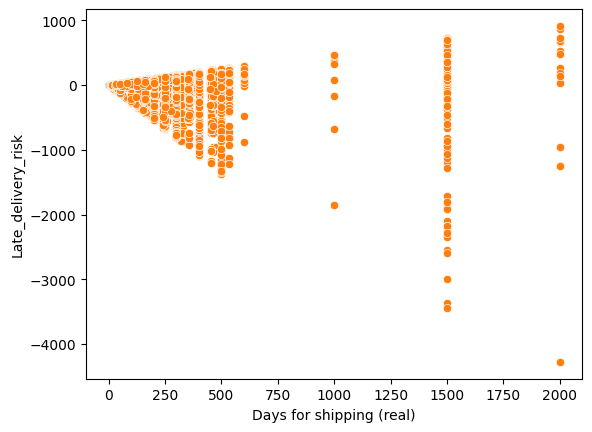

In [109]:
sns.scatterplot(x='Days for shipping (real)', y='Late_delivery_risk', data=non_obj_df)
sns.scatterplot(x='Sales', y='Order Profit Per Order', data=non_obj_df)


### Date Cols

In [94]:
date_df = df[date_cols].copy()
date_df.head()

,order date,shipping date
0,2018-01-31 22:56:00,2018-02-03 22:56:00
1,2018-01-13 12:27:00,2018-01-18 12:27:00
2,2018-01-13 12:06:00,2018-01-17 12:06:00
3,2018-01-13 11:45:00,2018-01-16 11:45:00
4,2018-01-13 11:24:00,2018-01-15 11:24:00


In [95]:
# Time-Base features
df['order_year'] = df['order date'].dt.year
df['order_month'] = df['order date'].dt.month
df['order_day'] = df['order date'].dt.day
df['order_weekday'] = df['order date'].dt.weekday  # 0=Mon, 6=Sun
df['order_week'] = df['order date'].dt.isocalendar().week

# Lead time days
df['lead_time_days'] = (df['shipping date'] - df['order date']).dt.days

# Seasonality / month indicators
df['is_weekend'] = df['order_weekday'].isin([5,6]).astype(int)
df['quarter'] = df['order date'].dt.quarter
